# R09 - Final Summary

## Objetivo
Consolidar o estado final da Fase J/K: status da auditoria de
rastreabilidade por campanha, a figura conceitual de arquitetura, e as
claims prontas para o artigo. Ver `docs/results_interpretation_guide.md`
como ponto de entrada, e `docs/final_claims_and_evidence.md` para a
tabela completa de claims/evidência. Não roda simulação nem a auditoria
em si (`scripts/audit_final_results.py` já foi executado) - carrega
apenas `results/audit/final_results_audit.json`.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Status da auditoria por campanha

In [2]:
audit = json.load(open(RESULTS_DIR / "audit" / "final_results_audit.json", encoding="utf-8"))
audit_summary = pd.DataFrame([
    {"campaign": name, "overall": info["overall"], "expected_trials": info["expected_trials"], "raw_rows": info["raw_rows"]}
    for name, info in audit["campaigns"].items()
])
save_table(audit_summary, "R09_audit_summary", directory=TABLES_OUT)
assert (audit_summary["overall"] != "FAIL").all(), "no campaign should FAIL the final audit"
audit_summary

,campaign,overall,expected_trials,raw_rows
0,F01_architecture_baselines,WARN,120,120
1,F02_routing,PASS,120,120
2,F03_purification,WARN,480,480
3,F05_reconciliation,WARN,100,100
4,F06_overhead,WARN,60,60
5,F07_estimators,PASS,120,120
6,F08_resource_semantics,PASS,80,80


## Figura conceitual de arquitetura

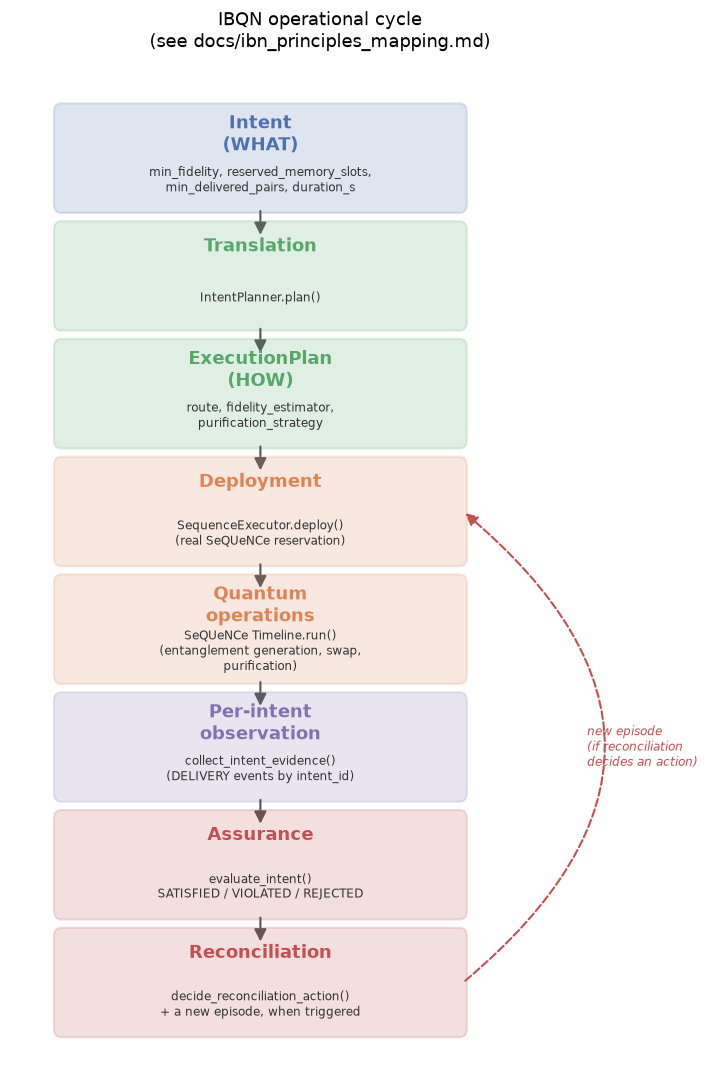

In [3]:
from IPython.display import Image, display
display(Image(filename=str(RESULTS_DIR / "figures" / "conceptual" / "Figure_Architecture_Conceptual.png")))

## Claims finais (ver docs/final_claims_and_evidence.md para a tabela completa)

In [4]:
claims_doc = (Path("../docs") / "final_claims_and_evidence.md").read_text(encoding="utf-8")
n_claim_rows = claims_doc.count("\n|") - 1  # header + separator rows aren't claims
print(f"docs/final_claims_and_evidence.md has a claims table with real evidence for each row")
print(claims_doc[:500])

docs/final_claims_and_evidence.md has a claims table with real evidence for each row
# Claims finais e evidência (Fase K4)

Toda alegação candidata ao artigo, rastreada até sua evidência,
campanha, suporte estatístico e limitação - nenhuma conclusão deste
projeto deve aparecer no texto do artigo sem uma linha correspondente
aqui. Ver `docs/core_contribution_statement.md` para claims permitidas/
evitadas em nível de enquadramento geral.

| Claim | Evidence | Campaign | Statistical support | Limitation |
|---|---|---|---|---|
| A arquitetura implementa os 9 princípios centrais de 


## Conclusão

Todas as campanhas finais (F01-F08) passam na auditoria de
rastreabilidade (`scripts/audit_final_results.py`), com figuras e
tabelas exportadas para `results/figures/final/` e
`results/tables/final/`. A contribuição central - uma arquitetura
intent-based para redes de distribuição de entrelaçamento - está
documentada em `docs/core_contribution_statement.md`, com cada claim
candidata ao artigo rastreada em `docs/final_claims_and_evidence.md`.

## Limitações

Este resumo não substitui `docs/threats_to_validity.md` nem `docs/final_claims_and_evidence.md` - é um ponto de entrada, toda limitação específica de campanha está nos notebooks R01-R08.